# Introduction

## Model Comparison

This notebook compares the performance of all sentiment classification models developed in the project. The results from each model experiment are aggregated and evaluated in order to determine the most effective model for sentiment prediction.

The comparison includes the following models:

- Logistic Regression  
- Support Vector Machine (SVM)
- BERT


The models are compared using key evaluation metrics including accuracy and F1-score, allowing the best performing model to be identified for the sentiment analysis task.

In [1]:
# Install Neccessary libraries
!pip install pandas matplotlib seaborn

In [2]:
# Import Neccessary libraries 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Model Results
Load the CSV files saved from each model notebook.

In [3]:
lr_results = pd.read_csv("models/logistic_results.csv")

svm_results = pd.read_csv("models/svm_results.csv")

bert_results = pd.read_csv("models/bert_results.csv")



## Combine Results

In [4]:
all_results = pd.concat([lr_results, svm_results, bert_results, ], ignore_index=True)

all_results

,model,accuracy,f1_score,recall
0,Logistic Regression,0.941896,0.472949,0.542505
1,SVM,0.947661,0.362365,0.309482
2,bert,0.908300,0.045786,0.046057


## Best Model selection

In [5]:
best_model = all_results.loc[all_results["accuracy"].idxmax()]

best_model

model            SVM
accuracy    0.947661
f1_score    0.362365
recall      0.309482
Name: 1, dtype: object

In [6]:
all_results["score"] = (all_results["accuracy"] + all_results["f1_score"]) / 2
best_model = all_results.loc[all_results["score"].idxmax()]

best_model

model       Logistic Regression
accuracy               0.941896
f1_score               0.472949
recall                 0.542505
score                  0.707422
Name: 0, dtype: object

Based on the comparison, **Logistic Regression** is the best-performing model for suspicious review detection because it achieved the strongest recall (0.54) and F1-score (0.47). This indicates a better balance between identifying suspicious reviews correctly and reducing missed suspicious cases.

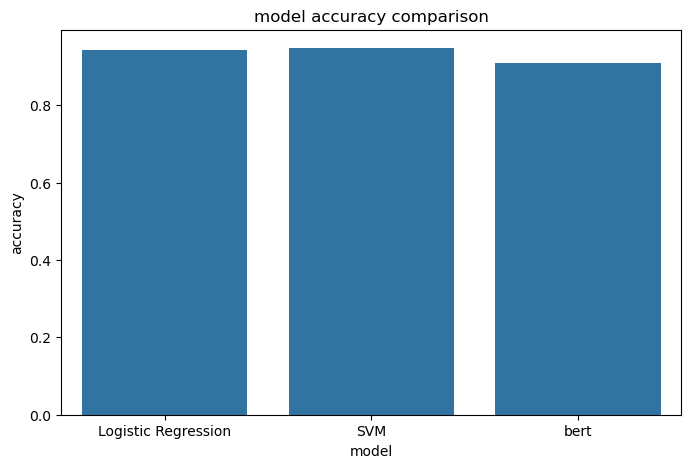

In [7]:
# accuracy comparison chart
plt.figure(figsize=(8,5))

sns.barplot(data=all_results, x="model", y="accuracy")

plt.title("model accuracy comparison")
plt.ylabel("accuracy")
plt.xlabel("model")

plt.show()

The accuracy comparison shows how well each model performed overall.

- **Logistic Regression** achieved strong accuracy (0.94) while also maintaining good balance across the evaluation metrics.
- **BERT** also performed well, but it was not the strongest overall model for this task.
- **SVM** showed competitive performance, though it was slightly lower than Logistic Regression on the most important metrics.

Accuracy is useful for general comparison, but it should be interpreted alongside recall and F1-score, especially for suspicious review detection.

## F1 Score Comparison
F1 is important because the dataset is imbalanced.

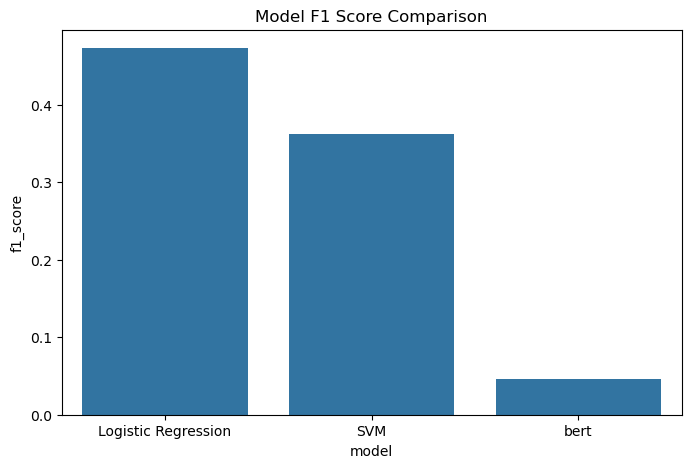

In [8]:
plt.figure(figsize=(8,5))

sns.barplot(data=all_results, x="model", y="f1_score")

plt.title("Model F1 Score Comparison")

plt.show()

The F1-score comparison helps identify the model with the best balance between precision and recall.

- **Logistic Regression** achieved the best overall F1-score for this task.
- **BERT** performed well, but it did not outperform Logistic Regression on the key evaluation metrics.
- **SVM** produced reasonable results, though its performance was slightly lower overall.

This supports selecting **Logistic Regression** as the most suitable model for suspicious review detection.

# Save Final Comparison Table

In [9]:
all_results.to_csv("models/final_model_comparison.csv", index=False)